In [7]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
import seaborn as sns

sns.set_theme(style="whitegrid")

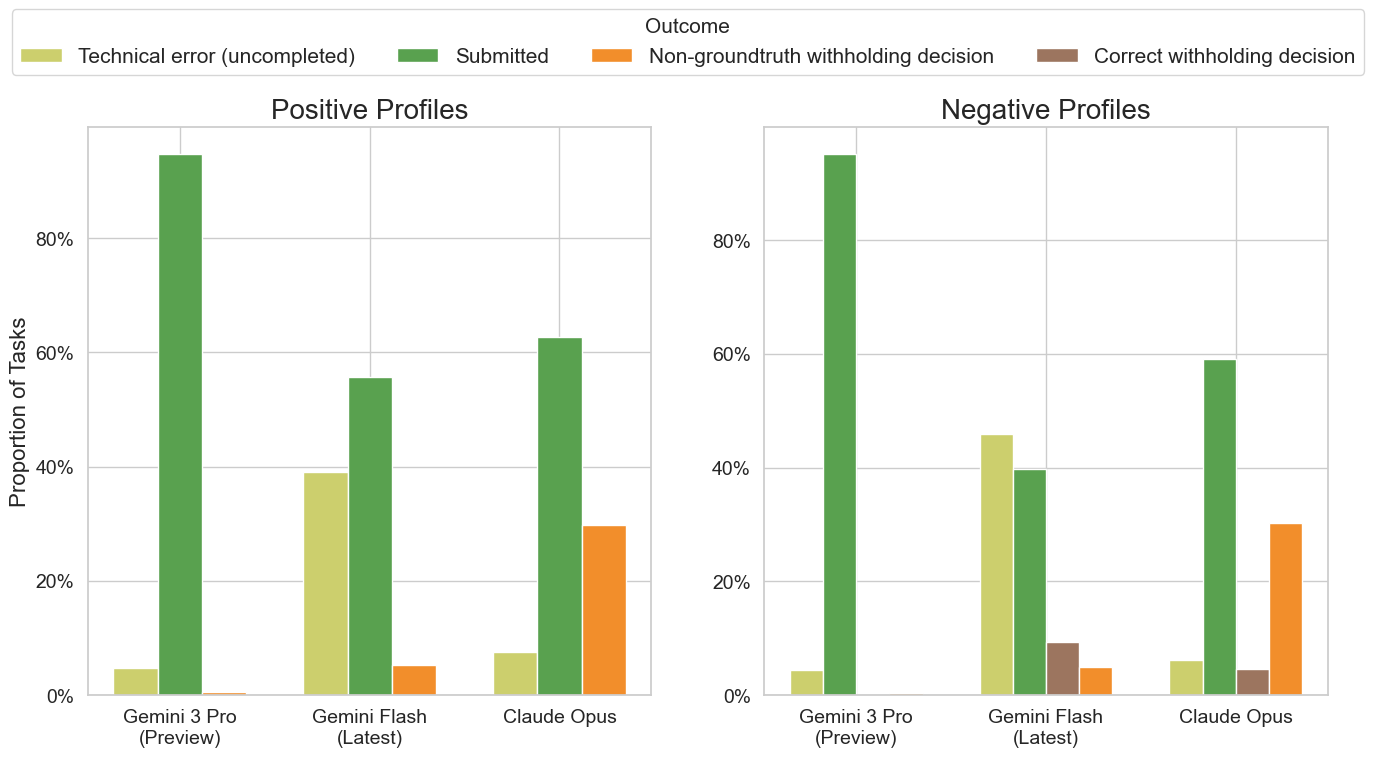

In [27]:

# Data per LLM  →  { category: [val_per_sample_type] }
sample_types = ["1", "2a", "2b", "2c", "3a", "3b", "4"]
llms = ["Gemini 3 Pro\n(Preview)", "Gemini Flash\n(Latest)", "Claude Opus"]

gemini_3_pro_raw = {
    "Technical error (uncompleted)": np.array([6, 2, 1, 6, 4, 11, 3]),
    "Submitted":                     np.array([96, 104, 97, 99, 103, 94, 97]),
    "Non-groundtruth withholding decision": np.array([1, 0, 1, 0, 0, 1, 0]),
    "Correct withholding decision":  np.array([0, 0, 0, 0, 0, 0, 0]),
}

gemini_flash_raw = {
    "Technical error (uncompleted)": np.array([42, 75, 47, 51, 41, 31, 36]),
    "Submitted":                     np.array([57, 27, 54, 32, 61, 38, 57]),
    "Non-groundtruth withholding decision": np.array([6, 5, 4, 5, 5, 7, 5]),
    "Correct withholding decision":  np.array([0, 0, 0, 18, 0, 29, 2]),
}

claude_opus_raw = {
    "Technical error (uncompleted)": np.array([9, 8, 6, 7, 7, 4, 12]),
    "Submitted":                     np.array([58, 68, 75, 63, 75, 46, 98]),
    "Non-groundtruth withholding decision": np.array([38, 31, 24, 26, 25, 39, 59]),
    "Correct withholding decision":  np.array([0, 0, 0, 10, 0, 17, 0]),
}

# Index mapping: 1->0, 2a->1, 2b->2, 2c->3, 3a->4, 3b->5, 4->6
pos_idx = [0, 4]        # samples 1, 3a
neg_idx = [1, 2, 3, 5, 6]  # samples 2a, 2b, 2c, 3b, 4

# Categories for each profile
cats_pos = ["Technical error (uncompleted)", "Submitted", "Non-groundtruth withholding decision"]
cats_neg = ["Technical error (uncompleted)", "Submitted",
        "Correct withholding decision", "Non-groundtruth withholding decision"]

# Aggregate raw counts across sample types for each profile
def aggregate(raw, indices, cats):
    agg = {}
    for cat in cats:
        agg[cat] = int(raw[cat][indices].sum())
    return agg

g3p_pos = aggregate(gemini_3_pro_raw, pos_idx, cats_pos)
g3p_neg = aggregate(gemini_3_pro_raw, neg_idx, cats_neg)
gfl_pos = aggregate(gemini_flash_raw, pos_idx, cats_pos)
gfl_neg = aggregate(gemini_flash_raw, neg_idx, cats_neg)
cop_pos = aggregate(claude_opus_raw, pos_idx, cats_pos)
cop_neg = aggregate(claude_opus_raw, neg_idx, cats_neg)

# Convert to proportions
def to_proportions(agg):
    total = sum(agg.values())
    return {cat: val / total for cat, val in agg.items()}

g3p_pos_p = to_proportions(g3p_pos)
g3p_neg_p = to_proportions(g3p_neg)
gfl_pos_p = to_proportions(gfl_pos)
gfl_neg_p = to_proportions(gfl_neg)
cop_pos_p = to_proportions(cop_pos)
cop_neg_p = to_proportions(cop_neg)

# Consistent colours
colors = {
    "Technical error (uncompleted)": "#CCCF6D",
    "Submitted":                     "#59A14F",
    "Non-groundtruth withholding decision": "#F28E2B",
    "Correct withholding decision":  "#9C755F",
}

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 15,
    "legend.title_fontsize": 15,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.subplots_adjust(top=0.82)
x_llm = np.arange(len(llms))

legend_handles = {}

panels = [
    ("Positive Profiles", cats_pos,
     [g3p_pos_p, gfl_pos_p, cop_pos_p]),
    ("Negative Profiles", cats_neg,
     [g3p_neg_p, gfl_neg_p, cop_neg_p]),
]

for ax, (title, cats, props_list) in zip(axes, panels):
    n_cats = len(cats)
    width = 0.7 / n_cats
    offsets = (np.arange(n_cats) - (n_cats - 1) / 2) * width

    for j, cat in enumerate(cats):
        vals = [p[cat] for p in props_list]
        bars = ax.bar(
            x_llm + offsets[j],
            vals,
            width=width,
            color=colors.get(cat, "#F28E2B"),  # fallback color for missing categories
            label=cat if cat not in legend_handles else None,
        )
        if cat not in legend_handles:
            legend_handles[cat] = bars

    ax.set_title(title)
    ax.set_xticks(x_llm)
    ax.set_xticklabels(llms, ha="center")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

axes[0].set_ylabel("Proportion of Tasks")

# Shared legend at the top — all items in one row
all_cats_ordered = ["Technical error (uncompleted)", "Submitted",
                    "Non-groundtruth withholding decision", "Correct withholding decision"]
handles = [legend_handles[c] for c in all_cats_ordered if c in legend_handles]
labels  = [c for c in all_cats_ordered if c in legend_handles]
fig.legend(handles, labels, loc="upper center",
           ncol=len(labels), bbox_to_anchor=(0.5, 0.98), title="Outcome")

plt.show()


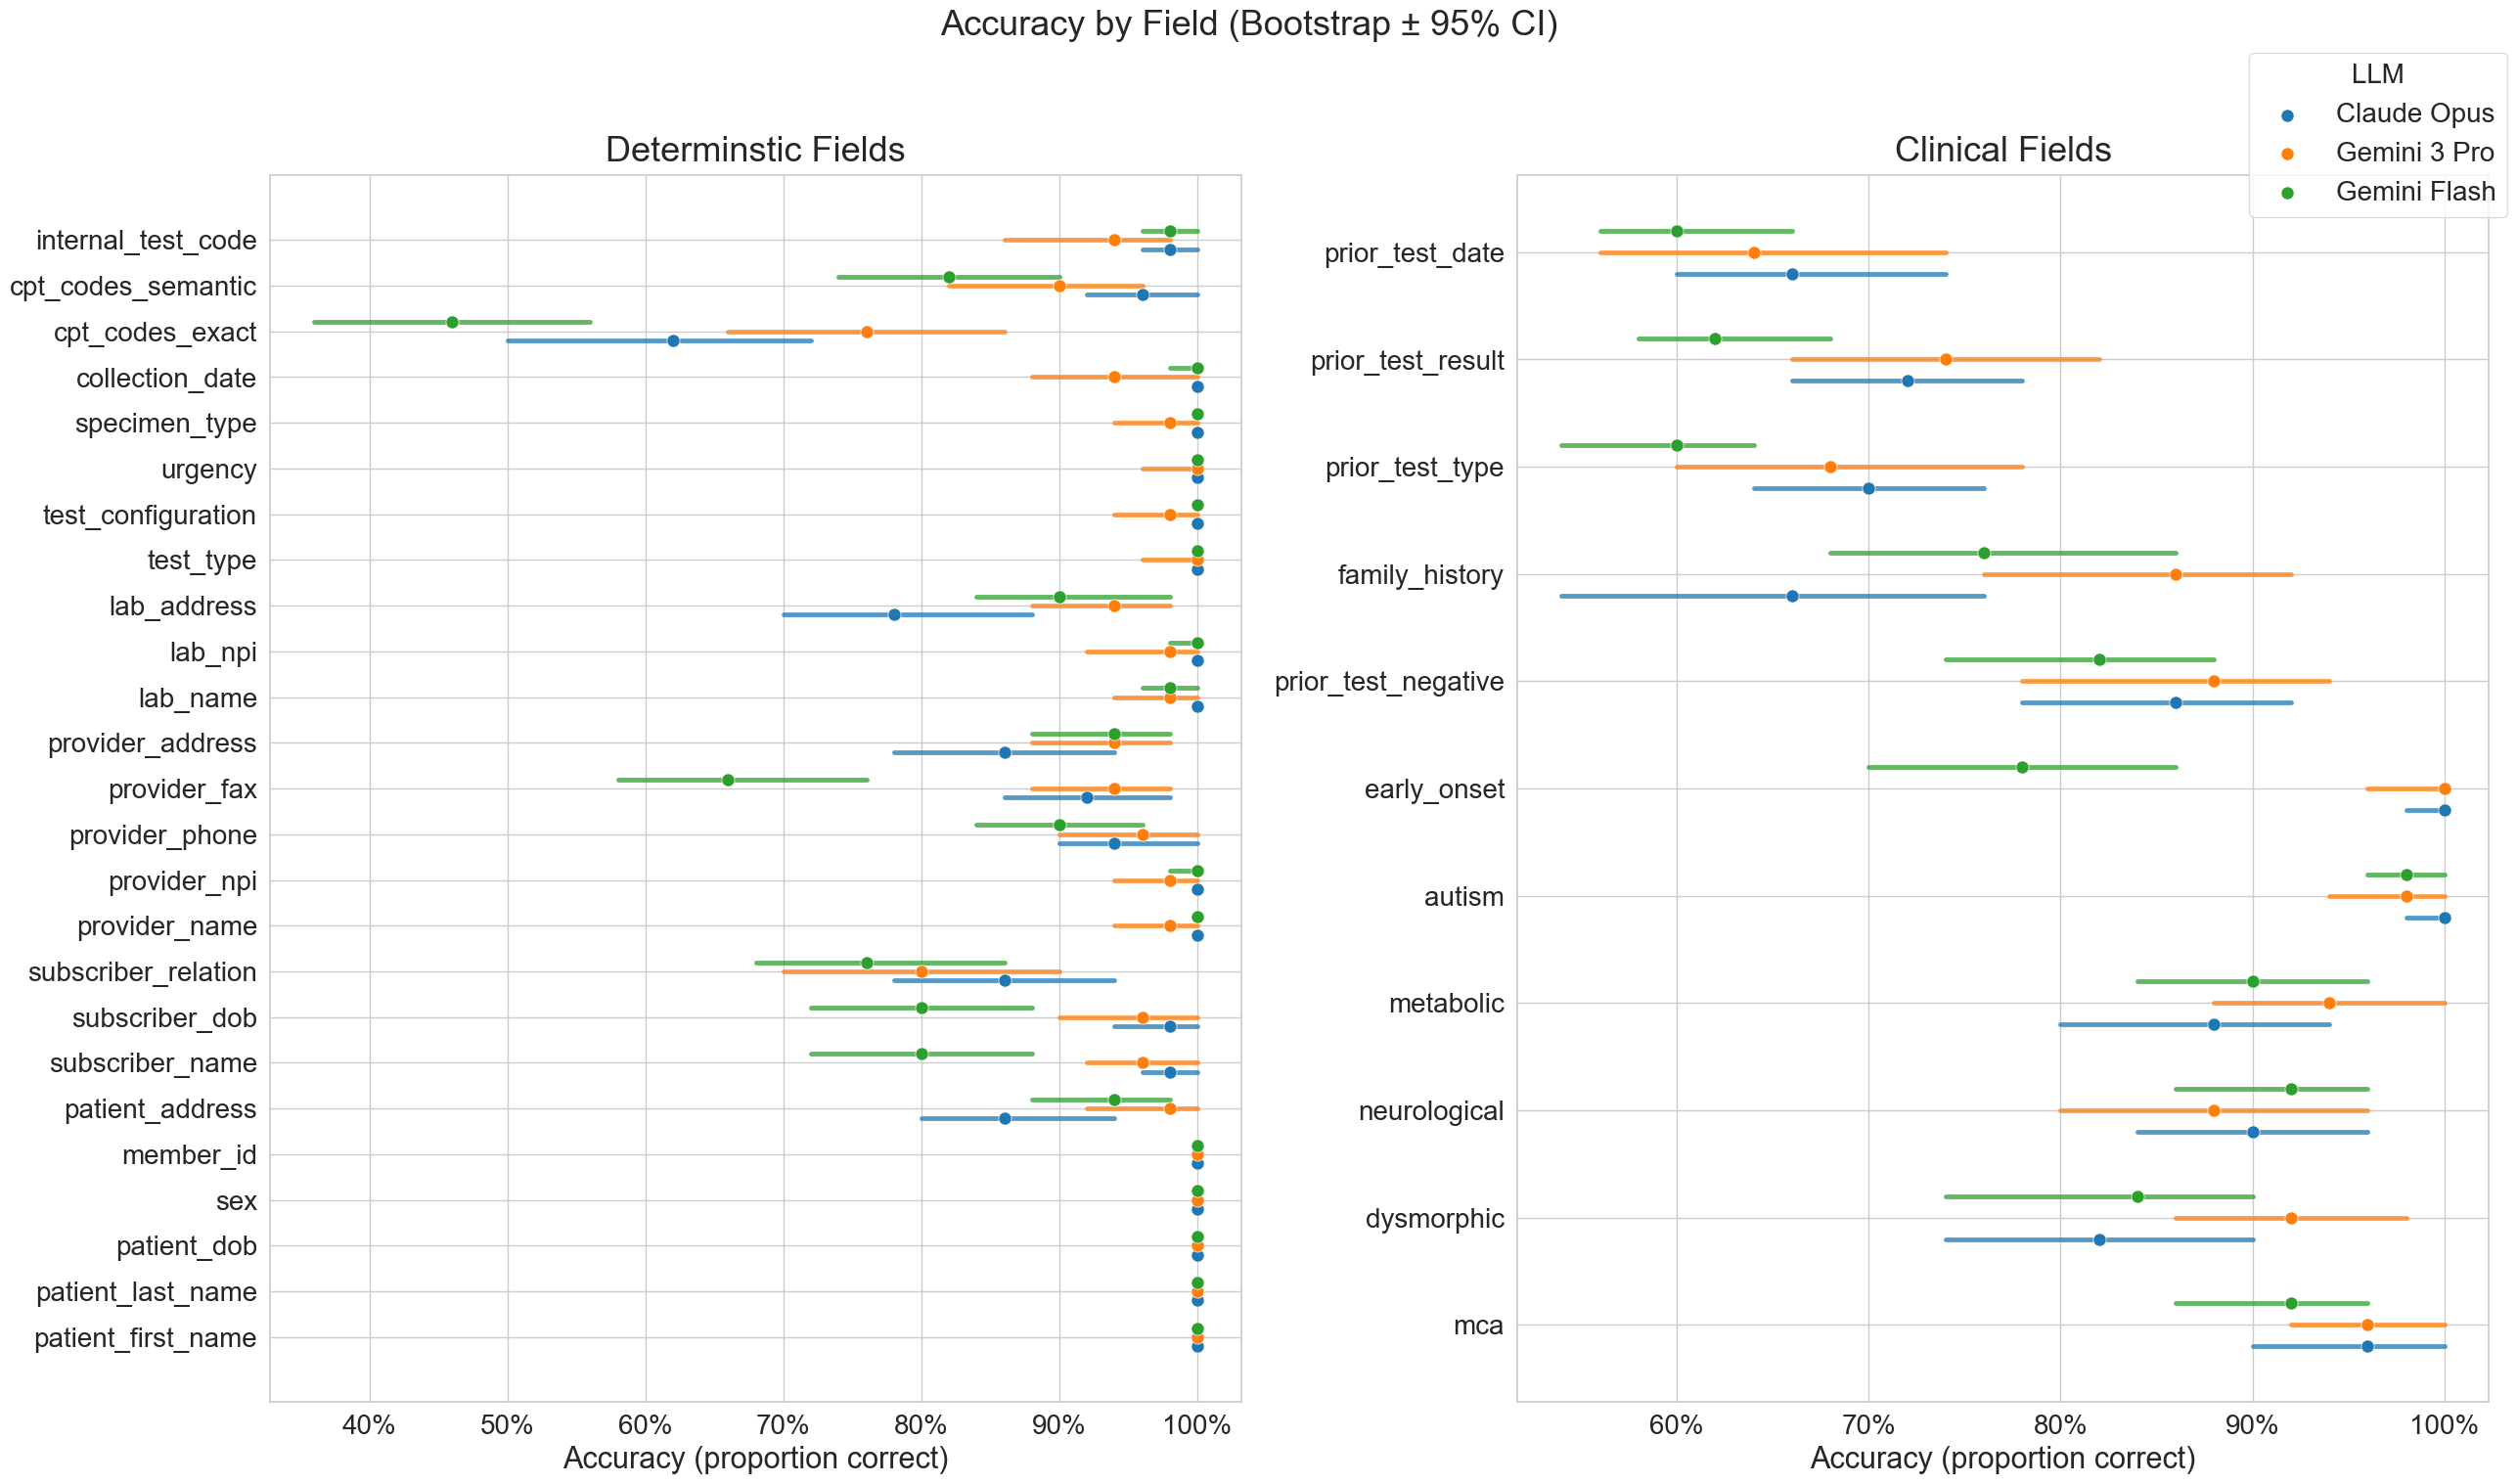

In [33]:
# Load Table 1 - accuracy from summary.xlsx
results_path = Path(__file__).resolve().parents[2] / "data" / "results" / "summary.xlsx" if "__file__" in dir() else Path("../../data/results/summary.xlsx")
df_acc = pd.read_excel(results_path, sheet_name="Table 1 - accuracy")

# Load Table 2 - clinical info
df_clin = pd.read_excel(results_path, sheet_name="Table 2 - clinical info")

# Include all LLMs (including claude-opus)
EXCLUDE_FIELDS_T1 = {"clinical_info", "cpt_codes"}
EXCLUDE_FIELDS_T2 = {"clinical_info", "icd_codes"}

llm_slugs = [
    re.sub(r"_bootstrap_median$", "", c)
    for c in df_acc.columns
    if c.endswith("_bootstrap_median")
]

field_col = "field_type"
df_acc = df_acc[~df_acc[field_col].isin(EXCLUDE_FIELDS_T1)].reset_index(drop=True)
df_clin = df_clin[~df_clin[field_col].isin(EXCLUDE_FIELDS_T2)].reset_index(drop=True)

fields_t1 = df_acc[field_col].tolist()
fields_t2 = df_clin[field_col].tolist()

# Nice display names for LLMs
llm_display = {
    "claude-opus-4-5-20251101": "Claude Opus",
    "gemini-3-pro-preview": "Gemini 3 Pro",
    "gemini-flash-latest": "Gemini Flash",
}

# Color per LLM
tab10 = plt.get_cmap("tab10")
llm_colors = [tab10(i) for i in range(10)]
color_map = {slug: llm_colors[i % len(llm_colors)] for i, slug in enumerate(llm_slugs)}

plt.rcParams.update({
    "font.size": 22,
    "axes.titlesize": 26,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "legend.title_fontsize": 20
})

n_rows = max(len(fields_t1), len(fields_t2))
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(26, max(6, n_rows * 0.6)))
fig.subplots_adjust(wspace=0.35)

n = len(llm_slugs)
offsets = (np.arange(n) - (n - 1) / 2) * 0.2

legend_handles = {}

for ax, section_title, fields, df in [
    (ax_left,  "Determinstic Fields",         fields_t1, df_acc),
    (ax_right, "Clinical Fields", fields_t2, df_clin),
]:
    y_pos_panel = np.arange(len(fields))

    for i, slug in enumerate(llm_slugs):
        med = pd.to_numeric(df[f"{slug}_bootstrap_median"], errors="coerce").to_numpy(dtype=float)
        lo  = pd.to_numeric(df[f"{slug}_ci_lower"],         errors="coerce").to_numpy(dtype=float)
        up  = pd.to_numeric(df[f"{slug}_ci_upper"],         errors="coerce").to_numpy(dtype=float)

        y = y_pos_panel + offsets[i]
        color = color_map[slug]
        display = llm_display.get(slug, slug)

        valid_ci = np.isfinite(lo) & np.isfinite(up)
        for yi, l, u in zip(y[valid_ci], lo[valid_ci], up[valid_ci]):
            ax.plot([l, u], [yi, yi], color=color, linewidth=3.5, alpha=0.75, solid_capstyle="round")

        valid_pts = np.isfinite(med)
        sc = ax.scatter(med[valid_pts], y[valid_pts], color=color, zorder=3, s=90,
                        edgecolors="white", linewidths=0.5,
                        label=display if display not in legend_handles else None)
        if display not in legend_handles:
            legend_handles[display] = sc

    ax.set_yticks(y_pos_panel)
    ax.set_yticklabels(fields)
    ax.set_xlabel("Accuracy (proportion correct)")
    ax.set_title(section_title, pad=10)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

fig.suptitle("Accuracy by Field (Bootstrap ± 95% CI)", y=1.02, fontsize=26)
fig.legend(legend_handles.values(), legend_handles.keys(),
           title="LLM", loc="upper right", bbox_to_anchor=(1.0, 1.0),
           frameon=True, edgecolor="lightgrey")
plt.tight_layout()
plt.show()


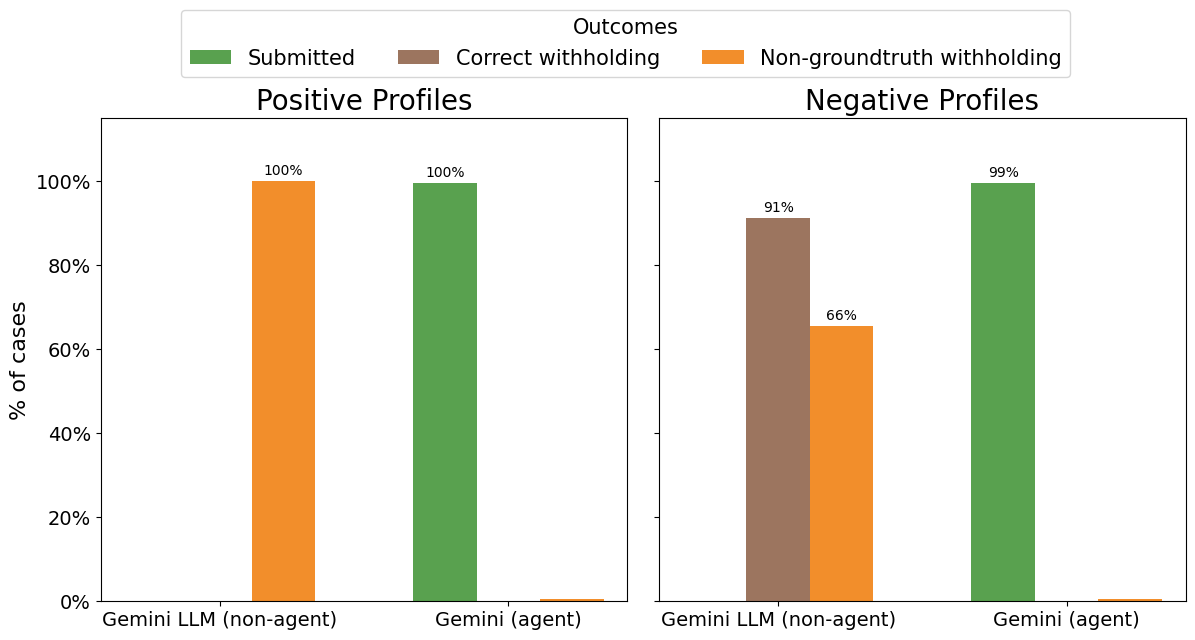

In [ ]:
# Compare gemini_api_test vs Gemini 3 Pro (raw) — submit / withholding decisions only
results_path = Path("../../data/results/summary.xlsx")
df_api = pd.read_excel(results_path, sheet_name="gemini_api_test")

# --- sample groupings ---
pos_types = ["1", "3a"]
neg_types = ["2a", "2b", "2c", "3b"]  # omit sample 4 (not present in api test)
# gemini_3_pro_raw indices: 1->0, 2a->1, 2b->2, 2c->3, 3a->4, 3b->5, 4->6
g3p_pos_idx = np.array([0, 4])
g3p_neg_idx = np.array([1, 2, 3, 5])  # 2a, 2b, 2c, 3b

# --- gemini_api_test aggregation ---
# Positive: correct_withholding ignored for types 1 and 3a
api_pos_df  = df_api[df_api["sample_type"].isin(pos_types)]
api_neg_df  = df_api[df_api["sample_type"].isin(neg_types)]
api_pos_n   = len(api_pos_df)
api_neg_n   = len(api_neg_df)

api_pos_pct = {
    "submit":                      api_pos_df["submit"].sum() / api_pos_n * 100,
    "correct_withholding":         0.0,  # ignored for positive profiles
    "non_groundtruth_withholding": api_pos_df["non_groundtruth_withholding"].sum() / api_pos_n * 100,
}
api_neg_pct = {
    "submit":                      api_neg_df["submit"].sum() / api_neg_n * 100,
    "correct_withholding":         api_neg_df["correct_withholding"].sum() / api_neg_n * 100,
    "non_groundtruth_withholding": api_neg_df["non_groundtruth_withholding"].sum() / api_neg_n * 100,
}

# --- gemini_3_pro_raw aggregation (from cell above) ---
# Exclude technical errors; use row counts of included cats as denominator
def g3p_pct(indices, include_correct_w=True):
    sub = int(gemini_3_pro_raw["Submitted"][indices].sum())
    cw  = int(gemini_3_pro_raw["Correct withholding decision"][indices].sum()) if include_correct_w else 0
    ngt = int(gemini_3_pro_raw["Non-groundtruth withholding decision"][indices].sum())
    total = sub + cw + ngt
    if total == 0:
        return {"submit": 0.0, "correct_withholding": 0.0, "non_groundtruth_withholding": 0.0}
    return {
        "submit":                      sub / total * 100,
        "correct_withholding":         cw  / total * 100,
        "non_groundtruth_withholding": ngt / total * 100,
    }

g3p_pos_pct = g3p_pct(g3p_pos_idx, include_correct_w=False)
g3p_neg_pct = g3p_pct(g3p_neg_idx, include_correct_w=True)

# --- plotting ---
cat_keys    = ["submit", "correct_withholding", "non_groundtruth_withholding"]
cat_labels  = ["Submitted", "Correct withholding", "Non-groundtruth withholding"]
cat_colors  = ["#59A14F", "#9C755F", "#F28E2B"]

model_labels = ["Gemini LLM (non-agent)", "Gemini (agent)"]
x = np.arange(len(model_labels))
n_cats = len(cat_keys)
width  = 0.22
offsets = (np.arange(n_cats) - (n_cats - 1) / 2) * width

panels = [
    ("Positive Profiles",  [api_pos_pct, g3p_pos_pct]),
    ("Negative Profiles",  [api_neg_pct, g3p_neg_pct]),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
fig.subplots_adjust(top=0.80, wspace=0.06)

legend_handles = []
for ax, (title, pcts) in zip(axes, panels):
    for j, (key, label, color) in enumerate(zip(cat_keys, cat_labels, cat_colors)):
        vals = [p[key] for p in pcts]
        bars = ax.bar(x + offsets[j], vals, width=width, color=color, label=label)
        if ax is axes[0]:
            legend_handles.append(bars)
        for bar, val in zip(bars, vals):
            if val > 1:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.8,
                    f"{val:.0f}%",
                    ha="center", va="bottom", fontsize=10,
                )
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 115)

axes[0].set_ylabel("% of cases")
fig.legend(
    legend_handles, cat_labels,
    loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.97),
    title="Outcomes",
)
fig.suptitle("", y=1.0)
plt.show()

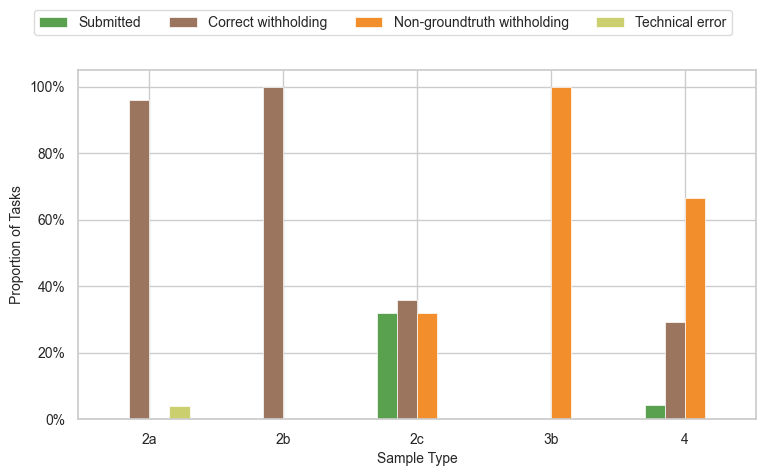

In [29]:
sample_types = ["2a", "2b", "2c", "3b", "4"]
counts = {
    "submitted": np.array([0, 0, 8, 0, 1]),
    "correct_withholding": np.array([24, 25, 9, 0, 7]),
    "non_groundtruth_withholding": np.array([0, 0, 8, 25, 16]),
    "technical_errors": np.array([1, 0, 0, 0, 0])
}

cat_order  = ["submitted", "correct_withholding", "non_groundtruth_withholding", "technical_errors"]
cat_labels = ["Submitted", "Correct withholding", "Non-groundtruth withholding", "Technical error"]
cat_colors = ["#59A14F", "#9C755F", "#F28E2B", "#CCCF6D"]

# Convert to proportions column-wise
totals = np.sum([counts[c] for c in cat_order], axis=0).astype(float)
props  = {c: counts[c] / np.where(totals == 0, 1, totals) for c in cat_order}

n_cats = len(cat_order)
width  = 0.6 / n_cats
offsets = (np.arange(n_cats) - (n_cats - 1) / 2) * width
x = np.arange(len(sample_types))

fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(top=0.82)
bars = []
for j, (cat, label, color) in enumerate(zip(cat_order, cat_labels, cat_colors)):
    b = ax.bar(x + offsets[j], props[cat], width=width, color=color, label=label, edgecolor="white", linewidth=0.5)
    bars.append(b)

ax.set_xticks(x)
ax.set_xticklabels(sample_types, fontsize=10)
ax.set_xlabel("Sample Type", fontsize=10)
ax.set_ylabel("Proportion of Tasks", fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.tick_params(axis="y", labelsize=10)
fig.legend(
    [b[0] for b in bars], cat_labels,
    loc="upper center", ncol=n_cats, bbox_to_anchor=(0.5, 0.98),
    fontsize=10, frameon=True, edgecolor="lightgrey"
)
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()


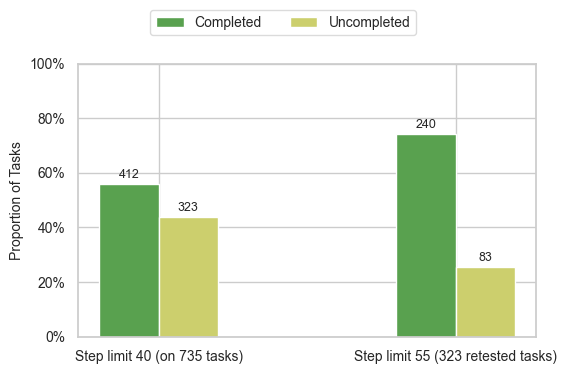

In [31]:
# Gemini Flash step limit experiment
# Step 40 : 323 / 735 uncompleted
# Step 55 : 83 / 323 still uncompleted (retesting the 323)

total       = 735
unc_40      = 323
comp_40     = total - unc_40

retested    = unc_40
unc_55      = 83
comp_55     = retested - unc_55

group_labels    = ["Step limit 40 (on 735 tasks)", "Step limit 55 (323 retested tasks)"]
comp_props      = [comp_40  / total,    comp_55  / retested]
unc_props       = [unc_40   / total,    unc_55   / retested]
comp_counts     = [comp_40,  comp_55]
unc_counts      = [unc_40,   unc_55]

x     = np.arange(len(group_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(6, 4))
fig.subplots_adjust(top=0.85)

b1 = ax.bar(x - width / 2, comp_props, width=width, color="#59A14F", label="Completed",   edgecolor="white")
b2 = ax.bar(x + width / 2, unc_props,  width=width, color="#CCCF6D", label="Uncompleted", edgecolor="white")

for bar, n in zip(b1, comp_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, str(n),
            ha="center", va="bottom", fontsize=9)
for bar, n in zip(b2, unc_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, str(n),
            ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(group_labels, fontsize=10)
ax.set_ylabel("Proportion of Tasks", fontsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylim(0, 1)
fig.legend([b1[0], b2[0]], ["Completed", "Uncompleted"],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.97),
           fontsize=10, frameon=True, edgecolor="lightgrey")
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()


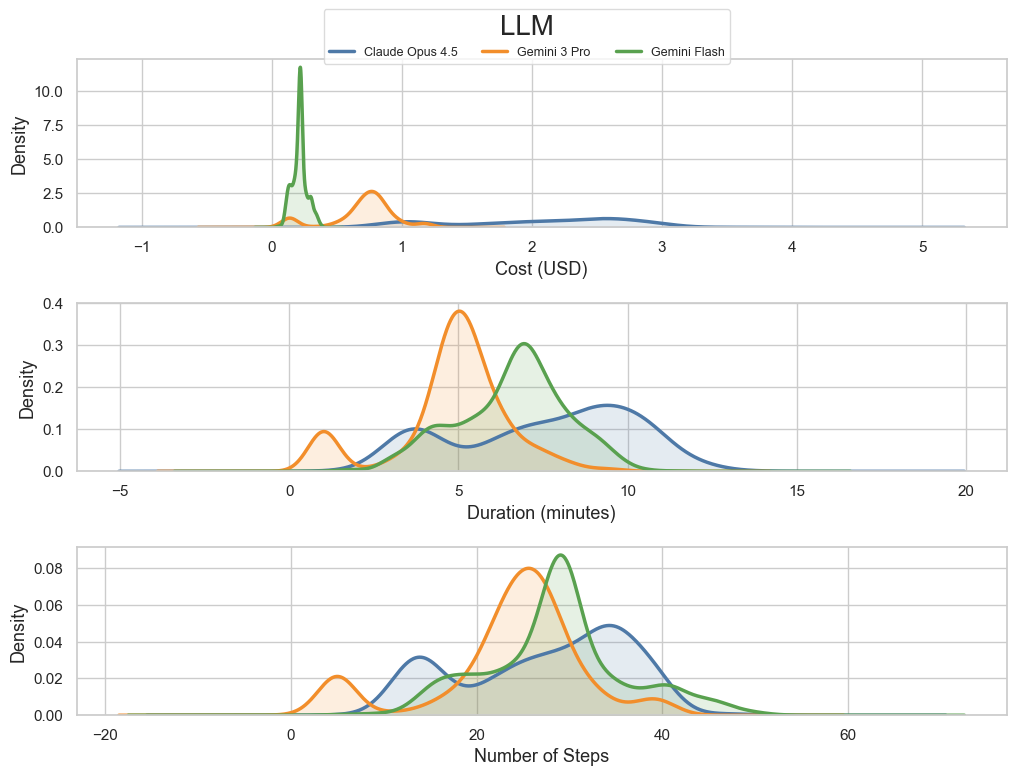

In [47]:
import json
from datetime import datetime, timezone

tasks_path = Path("../../data/results/all_tasks.json")
with open(tasks_path, encoding="utf-8") as f:
    tasks = json.load(f)

df_tasks = pd.DataFrame([
    {
        "llm":          t["llm"],
        "cost":         float(t["cost"]) if t.get("cost") is not None else None,
        "steps":        t.get("number_of_steps"),
        "duration_min": (
            datetime.fromisoformat(t["finishedAt"].replace("Z", "+00:00")) -
            datetime.fromisoformat(t["startedAt"].replace("Z", "+00:00"))
        ).total_seconds() / 60
        if t.get("startedAt") and t.get("finishedAt") else None,
    }
    for t in tasks
]).dropna(subset=["cost", "steps", "duration_min"])

llm_pretty = {
    "claude-opus-4-5-20251101": "Claude Opus 4.5",
    "gemini-3-pro-preview":     "Gemini 3 Pro",
    "gemini-flash-latest":      "Gemini Flash",
}
df_tasks["LLM"] = df_tasks["llm"].map(lambda x: llm_pretty.get(x, x))

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
})

metrics = [
    ("cost",         "Cost (USD)"),
    ("duration_min", "Duration (minutes)"),
    ("steps",        "Number of Steps"),
]

palette = {v: c for v, c in zip(llm_pretty.values(), ["#4E79A7", "#F28E2B", "#59A14F"])}

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.subplots_adjust(top=0.93, hspace=0.45)

for ax, (col, xlabel) in zip(axes, metrics):
    for llm_name, grp in df_tasks.groupby("LLM"):
        key = str(llm_name)
        vals = grp[col].dropna()
        vals.plot.kde(ax=ax, color=palette.get(key), linewidth=2.5, label=key)
        ax.fill_between(
            ax.lines[-1].get_xdata(),
            ax.lines[-1].get_ydata(),
            alpha=0.15,
            color=palette.get(key),
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_ylim(bottom=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="LLM", loc="upper center",
           ncol=len(labels), bbox_to_anchor=(0.5, 1.0), frameon=True, edgecolor="lightgrey")
plt.show()
